# Daechung Dam Water Level Forecasting with Horizon-wise LSTM

- Project: `daechung_waterlevel_lstm`
- Input file: `data/processed/merged_dam_weather_2006_2025_clean.csv`
- Features: K-water Daechung/Yongdam dam operation data + ASOS weather data
- Excluded: external river water-level station data (`water_level_2006_2025.csv`)
- Target: `수위_대청`
- Forecast horizons: 1, 3, 6, 9, 12 hours
- Window candidates: 8, 16, 24, 48, 72 hours
- Split: Train 2006–2017 / Validation 2018–2021 / Calibration 2022–2023 / Test 2024–2025
- Saves every trial model, loss history, params, validation predictions, and best-model calibration/test outputs.


In [1]:
# ============================================================
# Daechung Dam Water Level Forecasting with Horizon-wise LSTM
# Project: daechung_waterlevel_lstm
# ------------------------------------------------------------
# Model:
#   - Independent LSTM models for forecast horizons [1, 3, 6, 9, 12] hours
#   - Input window size is optimized by Optuna among [8, 16, 24, 48, 72]
#   - Train / Validation / Calibration / Test = 6 : 2 : 1 : 1
#     Train       : 2006-01-01 ~ 2017-12-31
#     Validation  : 2018-01-01 ~ 2021-12-31
#     Calibration : 2022-01-01 ~ 2023-12-31
#     Test        : 2024-01-01 ~ 2025-12-31
# ------------------------------------------------------------
# Input:
#   - data/processed/merged_dam_weather_2006_2025_clean.csv
#   - K-water Daechung/Yongdam clean hourly data
#   - ASOS weather clean hourly data
#   - External river water-level station data is excluded.
# ------------------------------------------------------------
# Important:
#   - Every trial's best model is saved.
#   - Every trial's loss history, parameters, and validation predictions are saved.
#   - Horizon-wise best model is additionally saved as best_overall_model.pt.
#   - Calibration and test predictions for best models are saved.
# ============================================================


In [2]:
# ============================================================
# 0. GPU Setting
# ============================================================

import os

# Use GPU 3 on the physical server. Inside PyTorch this becomes cuda:0.
os.environ["CUDA_VISIBLE_DEVICES"] = "3"


In [3]:
# ============================================================
# 1. Libraries
# ============================================================

from pathlib import Path
import random
import time
import joblib
import sys
import json
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

try:
    import optuna
    print("Optuna already installed:", optuna.__version__)
except ImportError:
    # This line works in Jupyter/IPython environments.
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", "optuna"])
    import optuna
    print("Optuna installed:", optuna.__version__)


Optuna already installed: 4.8.0


In [4]:
# ============================================================
# 2. Project Paths
# ============================================================

PROJECT_DIR = Path("/home/u2022144048/grad_project/daechung_waterlevel_lstm")

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = PROJECT_DIR / "logs"

for d in [
    RAW_DIR, INTERIM_DIR, PROCESSED_DIR,
    OUTPUT_DIR, MODEL_DIR, METRIC_DIR, FIGURE_DIR, LOG_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROCESSED_DIR / "merged_dam_weather_2006_2025_clean.csv"

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_PATH:", DATA_PATH)
print("DATA_PATH exists:", DATA_PATH.exists())


PROJECT_DIR: /home/u2022144048/grad_project/daechung_waterlevel_lstm
DATA_PATH: /home/u2022144048/grad_project/daechung_waterlevel_lstm/data/processed/merged_dam_weather_2006_2025_clean.csv
DATA_PATH exists: True


In [5]:
# ============================================================
# 3. Reproducibility & Device Check
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Device:", device)

if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device count: 1
Device: cuda:0
Using GPU: NVIDIA A100 80GB PCIe


In [6]:
# ============================================================
# 4. Load Data
# ============================================================

TIME_COL = "datetime"
TARGET_COL = "수위_대청"

df = pd.read_csv(DATA_PATH)

df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.sort_values(TIME_COL).reset_index(drop=True)

print("Data path:", DATA_PATH)
print("Data shape:", df.shape)
print("Time range:", df[TIME_COL].min(), "~", df[TIME_COL].max())
print("Missing total:", df.isna().sum().sum())
print("Duplicated datetime:", df[TIME_COL].duplicated().sum())

display(df.head())
display(df.tail())


Data path: /home/u2022144048/grad_project/daechung_waterlevel_lstm/data/processed/merged_dam_weather_2006_2025_clean.csv
Data shape: (175320, 45)
Time range: 2006-01-01 00:00:00 ~ 2025-12-31 23:00:00
Missing total: 0
Duplicated datetime: 0


,datetime,수위_대청,유입량_대청,방류량_대청,강우량_대청,저수량_대청,저수율_대청,수위_용담,유입량_용담,방류량_용담,...,Imsil_hm,Jeonju_hm,Boeun_ws,Buyeo_ws,Chungju_ws,Chupungnyeong_ws,Daejeon_ws,Geumsan_ws,Imsil_ws,Jeonju_ws
0,2006-01-01 00:00:00,69.53,133.0,133.0,0.0,839.621,56.4,248.91,0.0,12.5,...,91.0,80.0,0.0,1.2,1.0,0.8,1.6,0.0,0.3,0.8
1,2006-01-01 01:00:00,69.53,133.0,133.0,0.0,839.621,56.4,248.91,0.0,12.5,...,92.0,82.0,0.0,0.8,0.9,0.7,1.0,0.2,0.4,0.7
2,2006-01-01 02:00:00,69.51,0.0,78.2,0.0,838.660,56.3,248.91,12.4,12.4,...,95.0,82.0,0.1,0.1,1.2,0.4,0.0,0.2,0.0,0.2
3,2006-01-01 03:00:00,69.52,141.2,7.9,0.0,839.140,56.3,248.91,12.7,12.7,...,96.0,83.0,0.2,1.1,0.8,0.7,1.6,0.2,0.2,0.3
4,2006-01-01 04:00:00,69.53,141.5,7.9,0.0,839.621,56.4,248.91,12.4,12.4,...,96.0,84.0,0.0,0.0,1.2,0.0,0.8,0.0,0.5,0.7


,datetime,수위_대청,유입량_대청,방류량_대청,강우량_대청,저수량_대청,저수율_대청,수위_용담,유입량_용담,방류량_용담,...,Imsil_hm,Jeonju_hm,Boeun_ws,Buyeo_ws,Chungju_ws,Chupungnyeong_ws,Daejeon_ws,Geumsan_ws,Imsil_ws,Jeonju_ws
175315,2025-12-31 19:00:00,74.25,80.814,114.592,0.0,1053.519,70.7,257.71,9.074,27.602,...,40.0,43.0,1.1,1.2,2.3,4.3,3.2,2.0,1.2,4.1
175316,2025-12-31 20:00:00,74.25,46.019,115.297,0.0,1053.270,70.7,257.71,18.755,27.616,...,46.0,48.0,1.1,0.0,2.2,2.8,1.5,1.6,0.9,2.6
175317,2025-12-31 21:00:00,74.24,0.000,78.724,0.0,1052.923,70.7,257.71,3.482,27.621,...,49.0,47.0,1.1,0.1,1.4,4.4,1.8,1.4,1.6,2.9
175318,2025-12-31 22:00:00,74.24,45.363,11.585,0.0,1053.045,70.7,257.71,6.675,27.619,...,51.0,48.0,0.4,0.1,1.7,4.1,1.6,1.2,0.8,1.6
175319,2025-12-31 23:00:00,74.24,0.000,12.351,0.0,1052.911,70.7,257.70,3.494,27.633,...,58.0,50.0,0.9,0.0,2.3,4.1,1.9,0.9,0.4,1.5


In [7]:
# ============================================================
# 5. Feature Columns
# ============================================================

TARGET_COL = "수위_대청"

dam_cols = [
    "수위_대청",
    "유입량_대청",
    "방류량_대청",
    "강우량_대청",
    "저수량_대청",
    "저수율_대청",
    "수위_용담",
    "유입량_용담",
    "방류량_용담",
    "강우량_용담",
    "저수량_용담",
    "저수율_용담",
]

weather_cols = [
    c for c in df.columns
    if c.endswith("_ta")
    or c.endswith("_rn")
    or c.endswith("_hm")
    or c.endswith("_ws")
]

feature_cols = dam_cols + weather_cols
feature_cols = list(dict.fromkeys(feature_cols))

required_cols = [TIME_COL, TARGET_COL] + feature_cols
required_cols = list(dict.fromkeys(required_cols))

missing_cols = [c for c in required_cols if c not in df.columns]

print("Target:", TARGET_COL)
print("Dam cols:", len(dam_cols))
print("Weather cols:", len(weather_cols))
print("Total feature cols:", len(feature_cols))

print("\nFeature columns:")
for i, col in enumerate(feature_cols):
    print(f"{i:03d}: {col}")

if missing_cols:
    print("Missing columns:")
    print(missing_cols)
    raise ValueError("Some required columns are missing.")
else:
    print("All required columns exist.")


Target: 수위_대청
Dam cols: 12
Weather cols: 32
Total feature cols: 44

Feature columns:
000: 수위_대청
001: 유입량_대청
002: 방류량_대청
003: 강우량_대청
004: 저수량_대청
005: 저수율_대청
006: 수위_용담
007: 유입량_용담
008: 방류량_용담
009: 강우량_용담
010: 저수량_용담
011: 저수율_용담
012: Boeun_ta
013: Buyeo_ta
014: Chungju_ta
015: Chupungnyeong_ta
016: Daejeon_ta
017: Geumsan_ta
018: Imsil_ta
019: Jeonju_ta
020: Boeun_rn
021: Buyeo_rn
022: Chungju_rn
023: Chupungnyeong_rn
024: Daejeon_rn
025: Geumsan_rn
026: Imsil_rn
027: Jeonju_rn
028: Boeun_hm
029: Buyeo_hm
030: Chungju_hm
031: Chupungnyeong_hm
032: Daejeon_hm
033: Geumsan_hm
034: Imsil_hm
035: Jeonju_hm
036: Boeun_ws
037: Buyeo_ws
038: Chungju_ws
039: Chupungnyeong_ws
040: Daejeon_ws
041: Geumsan_ws
042: Imsil_ws
043: Jeonju_ws
All required columns exist.


In [8]:
# ============================================================
# 6. Numeric Cleaning
# ============================================================

selected_cols = list(dict.fromkeys(feature_cols + [TARGET_COL]))

for col in selected_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace(["", "nan", "NaN", "None", "-", " "], np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

missing_total = df[selected_cols].isna().sum().sum()

print("Selected columns:", len(selected_cols))
print("Missing total in selected cols:", missing_total)

if missing_total > 0:
    display(df[selected_cols].isna().sum().to_frame("missing_count").query("missing_count > 0"))
    raise ValueError("There are still missing values. Check clean file first.")

print("Target zero count:", (df[TARGET_COL] == 0).sum())
print("Target min:", df[TARGET_COL].min())
print("Target max:", df[TARGET_COL].max())

display(df[selected_cols].describe().T)


Selected columns: 44
Missing total in selected cols: 0
Target zero count: 0
Target min: 62.78
Target max: 79.21


,count,mean,std,min,25%,50%,75%,max
수위_대청,175320.0,71.071923,3.167985,62.780,68.760,71.530,73.5900,79.210
유입량_대청,175320.0,87.870145,711.720847,0.000,9.800,12.300,114.3860,276547.252
방류량_대청,175320.0,71.095883,163.817968,0.000,10.773,12.480,108.5595,3508.236
강우량_대청,175320.0,0.135223,0.767866,0.000,0.000,0.000,0.0000,40.300
저수량_대청,175320.0,881.935111,158.065029,487.230,767.026,891.582,1003.1480,1378.372
저수율_대청,175320.0,59.195036,10.608161,32.700,51.500,59.800,67.3000,92.500
수위_용담,175320.0,252.564120,5.799058,237.760,248.380,252.630,257.5100,265.450
유입량_용담,175320.0,28.327673,86.186264,0.000,11.346,15.522,23.5310,4394.922
방류량_용담,175320.0,21.909702,48.776366,0.000,14.275,16.569,24.3380,2919.454
강우량_용담,175320.0,0.157639,0.945443,0.000,0.000,0.000,0.0000,40.000


In [9]:
# ============================================================
# 7. Experiment Settings
# ============================================================

WINDOW_SIZE_CANDIDATES = [8, 16, 24, 48, 72]
FORECAST_HORIZON_LIST = [1, 3, 6, 9, 12]

# 6:2:1:1 split
# Train       : 2006-01-01 ~ 2017-12-31
# Validation  : 2018-01-01 ~ 2021-12-31
# Calibration : 2022-01-01 ~ 2023-12-31
# Test        : 2024-01-01 ~ 2025-12-31
TRAIN_END = "2018-01-01"
VAL_END = "2022-01-01"
CAL_END = "2024-01-01"

# Final run setting
N_TRIALS_PER_HORIZON = 20
MAX_EPOCHS = 80

# Stable early stopping setting
EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-5
MIN_EPOCHS = 15

EXPERIMENT_NAME = "lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es"

EXP_OUTPUT_DIR = OUTPUT_DIR / EXPERIMENT_NAME
EXP_MODEL_DIR = EXP_OUTPUT_DIR / "models"
EXP_RESULT_DIR = EXP_OUTPUT_DIR / "results"
EXP_FIGURE_DIR = EXP_OUTPUT_DIR / "figures"
EXP_LOG_DIR = LOG_DIR / EXPERIMENT_NAME

for d in [EXP_OUTPUT_DIR, EXP_MODEL_DIR, EXP_RESULT_DIR, EXP_FIGURE_DIR, EXP_LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Window candidates:", WINDOW_SIZE_CANDIDATES)
print("Forecast horizons:", FORECAST_HORIZON_LIST)
print("Trials per horizon:", N_TRIALS_PER_HORIZON)
print("Max epochs:", MAX_EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Min delta:", MIN_DELTA)
print("Min epochs:", MIN_EPOCHS)
print("Train end:", TRAIN_END)
print("Validation end:", VAL_END)
print("Calibration end:", CAL_END)
print("EXP_OUTPUT_DIR:", EXP_OUTPUT_DIR)
print("EXP_LOG_DIR:", EXP_LOG_DIR)


Window candidates: [8, 16, 24, 48, 72]
Forecast horizons: [1, 3, 6, 9, 12]
Trials per horizon: 20
Max epochs: 80
Early stopping patience: 10
Min delta: 1e-05
Min epochs: 15
Train end: 2018-01-01
Validation end: 2022-01-01
Calibration end: 2024-01-01
EXP_OUTPUT_DIR: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es
EXP_LOG_DIR: /home/u2022144048/grad_project/daechung_waterlevel_lstm/logs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es


In [10]:
# ============================================================
# 8. Metrics
# ============================================================

def nse_score(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    if denominator == 0:
        return np.nan

    numerator = np.sum((y_true - y_pred) ** 2)
    return 1 - numerator / denominator


def kge_score(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    if np.std(y_true) == 0 or np.mean(y_true) == 0:
        return np.nan

    r = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(r):
        return np.nan

    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)

    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mae_score(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def evaluate_predictions(y_true, y_pred):
    return {
        "NSE": nse_score(y_true, y_pred),
        "KGE": kge_score(y_true, y_pred),
        "RMSE": rmse_score(y_true, y_pred),
        "MAE": mae_score(y_true, y_pred),
    }


In [19]:
# ============================================================
# Persistence Baseline Check
# y_pred(t+h) = y(t)
# ============================================================

baseline_rows = []

for h in FORECAST_HORIZON_LIST:
    temp = df[[TIME_COL, TARGET_COL]].copy()
    temp["pred_persistence"] = temp[TARGET_COL].shift(h)
    temp = temp.dropna().copy()

    val_temp = temp[
        (temp[TIME_COL] >= pd.Timestamp(TRAIN_END)) &
        (temp[TIME_COL] < pd.Timestamp(VAL_END))
    ]

    cal_temp = temp[
        (temp[TIME_COL] >= pd.Timestamp(VAL_END)) &
        (temp[TIME_COL] < pd.Timestamp(CAL_END))
    ]

    test_temp = temp[
        temp[TIME_COL] >= pd.Timestamp(CAL_END)
    ]

    val_metrics = evaluate_predictions(
        val_temp[TARGET_COL].values,
        val_temp["pred_persistence"].values
    )

    cal_metrics = evaluate_predictions(
        cal_temp[TARGET_COL].values,
        cal_temp["pred_persistence"].values
    )

    test_metrics = evaluate_predictions(
        test_temp[TARGET_COL].values,
        test_temp["pred_persistence"].values
    )

    baseline_rows.append({
        "forecast_horizon": h,
        "val_NSE_persistence": val_metrics["NSE"],
        "val_KGE_persistence": val_metrics["KGE"],
        "val_RMSE_persistence": val_metrics["RMSE"],
        "val_MAE_persistence": val_metrics["MAE"],
        "cal_NSE_persistence": cal_metrics["NSE"],
        "cal_KGE_persistence": cal_metrics["KGE"],
        "cal_RMSE_persistence": cal_metrics["RMSE"],
        "cal_MAE_persistence": cal_metrics["MAE"],
        "test_NSE_persistence": test_metrics["NSE"],
        "test_KGE_persistence": test_metrics["KGE"],
        "test_RMSE_persistence": test_metrics["RMSE"],
        "test_MAE_persistence": test_metrics["MAE"],
    })

baseline_df = pd.DataFrame(baseline_rows)

baseline_path = EXP_RESULT_DIR / "persistence_baseline_metrics.csv"
baseline_df.to_csv(baseline_path, index=False, encoding="utf-8-sig")

print("Saved:", baseline_path)
display(baseline_df)


Saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/persistence_baseline_metrics.csv


,forecast_horizon,val_NSE_persistence,val_KGE_persistence,val_RMSE_persistence,val_MAE_persistence,cal_NSE_persistence,cal_KGE_persistence,cal_RMSE_persistence,cal_MAE_persistence,test_NSE_persistence,test_KGE_persistence,test_RMSE_persistence,test_MAE_persistence
0,1,0.999946,0.999973,0.013513,0.005840,0.999966,0.999960,0.013984,0.005593,0.999944,0.999965,0.013888,0.005766
1,3,0.999606,0.999803,0.036438,0.013313,0.999734,0.999829,0.038985,0.013909,0.999576,0.999778,0.038097,0.013341
2,6,0.998515,0.999257,0.070745,0.024148,0.998992,0.999452,0.075938,0.025499,0.998384,0.999182,0.074328,0.024329
3,9,0.996815,0.998407,0.103607,0.033965,0.997833,0.998869,0.111350,0.036389,0.996500,0.998240,0.109399,0.034424
4,12,0.994594,0.997297,0.134975,0.043666,0.996320,0.998110,0.145108,0.047257,0.993998,0.996989,0.143266,0.044787


In [20]:
# ============================================================
# Target distribution by split
# ============================================================

df_check = df[[TIME_COL, TARGET_COL]].copy()

splits = {
    "train": df_check[df_check[TIME_COL] < pd.Timestamp(TRAIN_END)],
    "val": df_check[
        (df_check[TIME_COL] >= pd.Timestamp(TRAIN_END)) &
        (df_check[TIME_COL] < pd.Timestamp(VAL_END))
    ],
    "cal": df_check[
        (df_check[TIME_COL] >= pd.Timestamp(VAL_END)) &
        (df_check[TIME_COL] < pd.Timestamp(CAL_END))
    ],
    "test": df_check[df_check[TIME_COL] >= pd.Timestamp(CAL_END)],
}

summary_rows = []

for name, d in splits.items():
    summary_rows.append({
        "split": name,
        "start": d[TIME_COL].min(),
        "end": d[TIME_COL].max(),
        "count": len(d),
        "mean": d[TARGET_COL].mean(),
        "std": d[TARGET_COL].std(),
        "min": d[TARGET_COL].min(),
        "max": d[TARGET_COL].max(),
        "zero_count": (d[TARGET_COL] == 0).sum(),
        "zero_ratio": (d[TARGET_COL] == 0).mean(),
        "na_count": d[TARGET_COL].isna().sum(),
    })

target_summary = pd.DataFrame(summary_rows)
display(target_summary)

,split,start,end,count,mean,std,min,max,zero_count,zero_ratio,na_count
0,train,2006-01-01,2017-12-31 23:00:00,105192,69.866406,3.183336,62.78,78.48,0,0.0,0
1,val,2018-01-01,2021-12-31 23:00:00,35064,73.395501,1.835798,68.59,79.21,0,0.0,0
2,cal,2022-01-01,2023-12-31 23:00:00,17520,71.724954,2.392220,67.43,77.69,0,0.0,0
3,test,2024-01-01,2025-12-31 23:00:00,17544,73.003961,1.849243,68.04,78.86,0,0.0,0


/tmp/ipykernel_764730/143657632.py:15: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_764730/143657632.py:15: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_764730/143657632.py:15: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_764730/143657632.py:15: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from current font.
  plt.tight_layout()
/usr/local/anaconda3/2024.02-1/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/anaconda3/2024.02-1/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/anaconda3/2024.

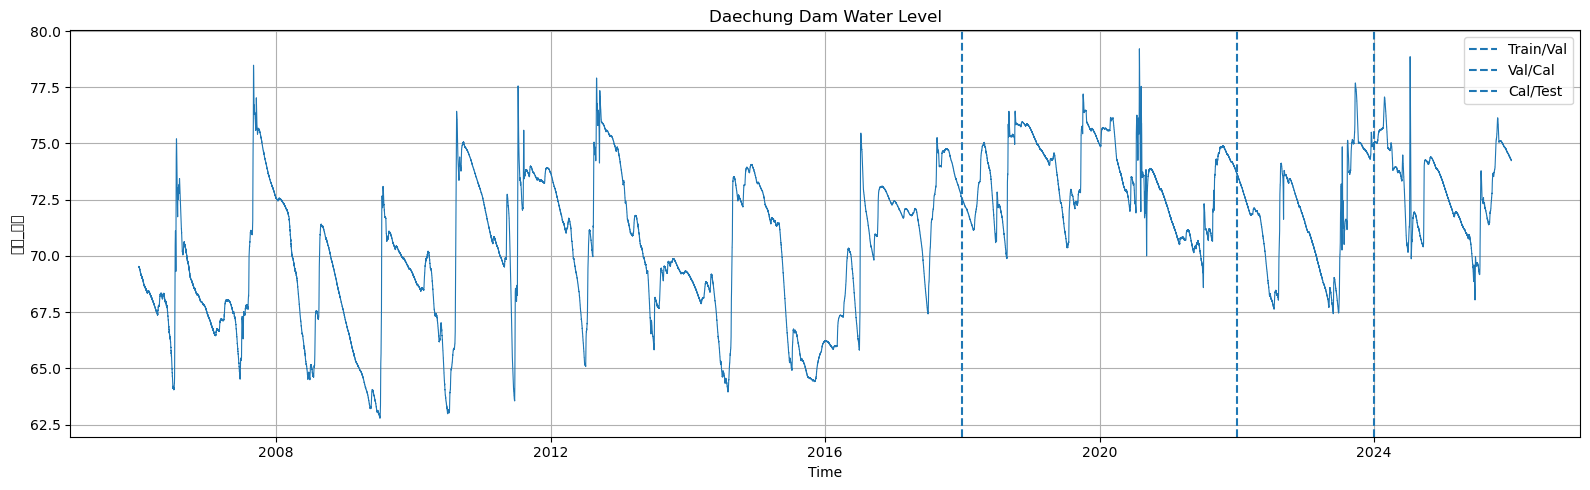

In [21]:
# ============================================================
# Plot Daechung water level by split
# ============================================================

plt.figure(figsize=(16, 5))
plt.plot(df[TIME_COL], df[TARGET_COL], linewidth=0.8)
plt.axvline(pd.Timestamp(TRAIN_END), linestyle="--", label="Train/Val")
plt.axvline(pd.Timestamp(VAL_END), linestyle="--", label="Val/Cal")
plt.axvline(pd.Timestamp(CAL_END), linestyle="--", label="Cal/Test")
plt.xlabel("Time")
plt.ylabel(TARGET_COL)
plt.title("Daechung Dam Water Level")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 9. Window Dataset Function
# ============================================================

def make_window_dataset(X_values, y_values, time_values, window_size=72, forecast_horizon=1):
    X_windows = []
    y_windows = []
    target_times = []

    n = len(X_values)

    for i in range(window_size, n - forecast_horizon + 1):
        X_windows.append(X_values[i - window_size:i, :])
        y_windows.append(y_values[i + forecast_horizon - 1, :])
        target_times.append(time_values[i + forecast_horizon - 1])

    X_windows = np.array(X_windows, dtype=np.float32)
    y_windows = np.array(y_windows, dtype=np.float32)
    target_times = np.array(target_times)

    return X_windows, y_windows, target_times


In [23]:
# ============================================================
# 10. PyTorch Dataset
# ============================================================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [24]:
# ============================================================
# 11. LSTM Model
# ============================================================

class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        dropout=0.2,
        dense_size=64
    ):
        super().__init__()

        lstm_dropout = dropout if num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]

        x = self.dropout(last_hidden)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        output = self.fc2(x)

        return output


In [25]:
# ============================================================
# 12. Train / Evaluation Functions
# ============================================================

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(train_loader.dataset)


def evaluate_loss(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(data_loader.dataset)


def predict_model(model, data_loader, device):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)

            preds.append(y_pred.cpu().numpy())
            trues.append(y_batch.cpu().numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    return trues, preds


def train_model_for_trial(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    max_epochs=80,
    patience=10,
    min_delta=1e-5,
    min_epochs=15
):
    best_val_loss = np.inf
    best_epoch = 0
    best_state_dict = None
    patience_counter = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss = evaluate_loss(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device
        )

        improved = val_loss < (best_val_loss - min_delta)

        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            if epoch >= min_epochs:
                patience_counter += 1
            else:
                patience_counter = 0

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss_so_far": best_val_loss,
            "best_epoch_so_far": best_epoch,
            "patience_counter": patience_counter,
            "improved": improved
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Best Val Loss: {best_val_loss:.6f} | "
            f"Best Epoch: {best_epoch} | "
            f"Patience: {patience_counter}/{patience}"
        )

        if epoch >= min_epochs and patience_counter >= patience:
            print(
                f"Early stopping at epoch {epoch} | "
                f"Best epoch: {best_epoch} | "
                f"Best val_loss: {best_val_loss:.6f}"
            )
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    history_df = pd.DataFrame(history)

    return best_val_loss, best_epoch, best_state_dict, history_df

In [26]:
# ============================================================
# 13. Horizon-wise Optuna Function
# ============================================================

def run_optuna_for_horizon(forecast_horizon):
    print("\n" + "#" * 100)
    print(f"Forecast Horizon: {forecast_horizon}h")
    print("#" * 100)

    MODEL_DIR_H = EXP_MODEL_DIR / f"horizon_{forecast_horizon}"
    LOG_DIR_H = EXP_LOG_DIR / f"horizon_{forecast_horizon}"
    RESULT_DIR_H = EXP_RESULT_DIR / f"horizon_{forecast_horizon}"
    FIGURE_DIR_H = EXP_FIGURE_DIR / f"horizon_{forecast_horizon}"

    for d in [MODEL_DIR_H, LOG_DIR_H, RESULT_DIR_H, FIGURE_DIR_H]:
        d.mkdir(parents=True, exist_ok=True)

    trial_summaries = []

    def objective(trial):
        start_time = time.time()

        window_size = trial.suggest_categorical("window_size", WINDOW_SIZE_CANDIDATES)
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
        num_layers = trial.suggest_categorical("num_layers", [1, 2])
        dropout = trial.suggest_float("dropout", 0.0, 0.4)
        dense_size = trial.suggest_categorical("dense_size", [16, 32, 64, 128])
        learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True)
        batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
        patience = EARLY_STOPPING_PATIENCE

        print("\n" + "=" * 90)
        print(f"Horizon {forecast_horizon}h | Trial {trial.number} started")
        print("Parameters:")
        print(f"  window_size: {window_size}")
        print(f"  hidden_size: {hidden_size}")
        print(f"  num_layers: {num_layers}")
        print(f"  dropout: {dropout}")
        print(f"  dense_size: {dense_size}")
        print(f"  learning_rate: {learning_rate}")
        print(f"  weight_decay: {weight_decay}")
        print(f"  batch_size: {batch_size}")
        print(f"  patience: {patience}")
        print("=" * 90)

        # Scaling only on the train period to avoid data leakage.
        train_mask_raw = df[TIME_COL] < TRAIN_END
        train_df_for_scaler = df.loc[train_mask_raw].copy()

        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        scaler_X.fit(train_df_for_scaler[feature_cols].values)
        scaler_y.fit(train_df_for_scaler[[TARGET_COL]].values)

        X_all_scaled = scaler_X.transform(df[feature_cols].values)
        y_all_scaled = scaler_y.transform(df[[TARGET_COL]].values)

        X, y, target_times = make_window_dataset(
            X_values=X_all_scaled,
            y_values=y_all_scaled,
            time_values=df[TIME_COL].values,
            window_size=window_size,
            forecast_horizon=forecast_horizon
        )

        target_times = pd.to_datetime(target_times)

        train_mask = target_times < TRAIN_END
        val_mask = (target_times >= TRAIN_END) & (target_times < VAL_END)
        cal_mask = (target_times >= VAL_END) & (target_times < CAL_END)
        test_mask = target_times >= CAL_END

        X_train, y_train = X[train_mask], y[train_mask]
        X_val, y_val = X[val_mask], y[val_mask]
        X_cal, y_cal = X[cal_mask], y[cal_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        time_train = target_times[train_mask]
        time_val = target_times[val_mask]
        time_cal = target_times[cal_mask]
        time_test = target_times[test_mask]

        if len(X_train) == 0 or len(X_val) == 0 or len(X_cal) == 0 or len(X_test) == 0:
            raise ValueError("Empty train/val/cal/test split. Check dates and window settings.")

        train_dataset = TimeSeriesDataset(X_train, y_train)
        val_dataset = TimeSeriesDataset(X_val, y_val)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

        iter_per_epoch = int(np.ceil(len(X_train) / batch_size))
        max_possible_iterations = iter_per_epoch * MAX_EPOCHS

        print(f"Train samples: {len(X_train)}")
        print(f"Validation samples: {len(X_val)}")
        print(f"Calibration samples: {len(X_cal)}")
        print(f"Test samples: {len(X_test)}")
        print(f"Iterations per epoch: {iter_per_epoch}")
        print(f"Max possible iterations: {max_possible_iterations}")

        model = LSTMRegressor(
            input_size=X_train.shape[2],
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            dense_size=dense_size
        ).to(device)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

        best_val_loss, best_epoch, best_state_dict, history_df = train_model_for_trial(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            max_epochs=MAX_EPOCHS,
            patience=patience,
            min_delta=MIN_DELTA,
            min_epochs=MIN_EPOCHS
        )

        if best_state_dict is None:
            raise RuntimeError("best_state_dict is None.")

        actual_epochs = len(history_df)
        actual_total_iterations = iter_per_epoch * actual_epochs

        print(f"Actual epochs: {actual_epochs}")
        print(f"Actual total iterations: {actual_total_iterations}")

        model.load_state_dict(best_state_dict)
        model.eval()

        y_val_scaled_true, y_val_scaled_pred = predict_model(
            model=model,
            data_loader=val_loader,
            device=device
        )

        y_val_true = scaler_y.inverse_transform(y_val_scaled_true)
        y_val_pred = scaler_y.inverse_transform(y_val_scaled_pred)

        val_metrics = evaluate_predictions(y_val_true, y_val_pred)

        val_nse = val_metrics["NSE"]
        val_kge = val_metrics["KGE"]
        val_rmse = val_metrics["RMSE"]
        val_mae = val_metrics["MAE"]

        objective_value = -1e9 if np.isnan(val_nse) else val_nse

        elapsed_time = time.time() - start_time

        print("-" * 90)
        print(f"Horizon {forecast_horizon}h | Trial {trial.number} finished")
        print(f"Best epoch    : {best_epoch}")
        print(f"Best val_loss : {best_val_loss:.6f}")
        print(f"Val NSE       : {val_nse:.4f}")
        print(f"Val KGE       : {val_kge:.4f}")
        print(f"Val RMSE      : {val_rmse:.4f}")
        print(f"Val MAE       : {val_mae:.4f}")
        print(f"Elapsed time  : {elapsed_time / 60:.2f} min")
        print("-" * 90)

        trial_model_path = MODEL_DIR_H / f"trial_{trial.number:03d}_best_model.pt"
        trial_history_path = LOG_DIR_H / f"trial_{trial.number:03d}_history.csv"
        trial_params_path = LOG_DIR_H / f"trial_{trial.number:03d}_params.json"
        trial_val_pred_path = RESULT_DIR_H / f"trial_{trial.number:03d}_val_predictions.csv"
        trial_scaler_x_path = MODEL_DIR_H / f"trial_{trial.number:03d}_scaler_X.pkl"
        trial_scaler_y_path = MODEL_DIR_H / f"trial_{trial.number:03d}_scaler_y.pkl"

        checkpoint = {
            "model_state_dict": best_state_dict,
            "trial_number": trial.number,
            "forecast_horizon": forecast_horizon,
            "window_size": window_size,
            "params": {
                "window_size": window_size,
                "hidden_size": hidden_size,
                "num_layers": num_layers,
                "dropout": dropout,
                "dense_size": dense_size,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "batch_size": batch_size,
                "patience": patience,
            },
            "feature_cols": feature_cols,
            "target_col": TARGET_COL,
            "best_epoch": best_epoch,
            "best_val_loss": float(best_val_loss),
            "train_samples": int(len(X_train)),
            "val_samples": int(len(X_val)),
            "cal_samples": int(len(X_cal)),
            "test_samples": int(len(X_test)),
            "iterations_per_epoch": int(iter_per_epoch),
            "actual_epochs": int(actual_epochs),
            "actual_total_iterations": int(actual_total_iterations),
            "max_possible_iterations": int(max_possible_iterations),
            "val_metrics": {
                "NSE": float(val_nse),
                "KGE": float(val_kge),
                "RMSE": float(val_rmse),
                "MAE": float(val_mae),
            },
            "train_period": [str(time_train.min()), str(time_train.max())],
            "val_period": [str(time_val.min()), str(time_val.max())],
            "cal_period": [str(time_cal.min()), str(time_cal.max())],
            "test_period": [str(time_test.min()), str(time_test.max())],
        }

        torch.save(checkpoint, trial_model_path)
        joblib.dump(scaler_X, trial_scaler_x_path)
        joblib.dump(scaler_y, trial_scaler_y_path)

        history_df["trial_number"] = trial.number
        history_df["forecast_horizon"] = forecast_horizon
        history_df["window_size"] = window_size
        history_df["hidden_size"] = hidden_size
        history_df["num_layers"] = num_layers
        history_df["dropout"] = dropout
        history_df["dense_size"] = dense_size
        history_df["learning_rate"] = learning_rate
        history_df["weight_decay"] = weight_decay
        history_df["batch_size"] = batch_size
        history_df["patience"] = patience
        history_df["best_epoch"] = best_epoch
        history_df["train_samples"] = int(len(X_train))
        history_df["iterations_per_epoch"] = int(iter_per_epoch)
        history_df["actual_epochs"] = int(actual_epochs)
        history_df["actual_total_iterations"] = int(actual_total_iterations)

        history_df.to_csv(trial_history_path, index=False, encoding="utf-8-sig")

        val_pred_df = pd.DataFrame({
            "datetime": time_val,
            "observed": y_val_true.reshape(-1),
            "predicted": y_val_pred.reshape(-1),
            "forecast_horizon": forecast_horizon,
            "trial_number": trial.number,
            "window_size": window_size,
        })

        val_pred_df.to_csv(trial_val_pred_path, index=False, encoding="utf-8-sig")

        trial_params = {
            "trial_number": trial.number,
            "forecast_horizon": forecast_horizon,
            "window_size": window_size,
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "dropout": dropout,
            "dense_size": dense_size,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "patience": patience,
            "best_epoch": best_epoch,
            "best_val_loss": float(best_val_loss),
            "train_samples": int(len(X_train)),
            "val_samples": int(len(X_val)),
            "cal_samples": int(len(X_cal)),
            "test_samples": int(len(X_test)),
            "iterations_per_epoch": int(iter_per_epoch),
            "actual_epochs": int(actual_epochs),
            "actual_total_iterations": int(actual_total_iterations),
            "max_possible_iterations": int(max_possible_iterations),
            "val_nse": float(val_nse),
            "val_kge": float(val_kge),
            "val_rmse": float(val_rmse),
            "val_mae": float(val_mae),
            "elapsed_min": float(elapsed_time / 60),
        }

        with open(trial_params_path, "w", encoding="utf-8") as f:
            json.dump(trial_params, f, ensure_ascii=False, indent=4)

        trial_summaries.append(trial_params)

        pd.DataFrame(trial_summaries).to_csv(
            LOG_DIR_H / "trials_summary_live.csv",
            index=False,
            encoding="utf-8-sig"
        )

        return objective_value

    study = optuna.create_study(
        direction="maximize",
        study_name=f"Daechung_LSTM_horizon_{forecast_horizon}"
    )

    study.optimize(objective, n_trials=N_TRIALS_PER_HORIZON)

    trials_summary_df = pd.DataFrame(trial_summaries)
    trials_summary_df.to_csv(LOG_DIR_H / "trials_summary.csv", index=False, encoding="utf-8-sig")

    optuna_df = study.trials_dataframe()
    optuna_df.to_csv(LOG_DIR_H / "optuna_trials_dataframe.csv", index=False, encoding="utf-8-sig")

    best_trial_number = study.best_trial.number

    best_checkpoint_path = MODEL_DIR_H / f"trial_{best_trial_number:03d}_best_model.pt"
    best_scaler_x_path = MODEL_DIR_H / f"trial_{best_trial_number:03d}_scaler_X.pkl"
    best_scaler_y_path = MODEL_DIR_H / f"trial_{best_trial_number:03d}_scaler_y.pkl"

    best_overall_path = MODEL_DIR_H / "best_overall_model.pt"
    best_overall_scaler_x_path = MODEL_DIR_H / "best_overall_scaler_X.pkl"
    best_overall_scaler_y_path = MODEL_DIR_H / "best_overall_scaler_y.pkl"

    shutil.copy(best_checkpoint_path, best_overall_path)
    shutil.copy(best_scaler_x_path, best_overall_scaler_x_path)
    shutil.copy(best_scaler_y_path, best_overall_scaler_y_path)

    print("\nBest trial for horizon", forecast_horizon)
    print("Best value:", study.best_value)
    print("Best params:", study.best_params)
    print("Best overall model saved:", best_overall_path)

    return {
        "forecast_horizon": forecast_horizon,
        "best_trial_number": best_trial_number,
        "best_val_nse": study.best_value,
        "best_params": study.best_params,
        "model_dir": str(MODEL_DIR_H),
        "log_dir": str(LOG_DIR_H),
        "result_dir": str(RESULT_DIR_H),
    }


In [27]:
# ============================================================
# 14. Run Optuna for All Horizons
# ============================================================

all_best_results = []

for horizon in FORECAST_HORIZON_LIST:
    result = run_optuna_for_horizon(horizon)
    all_best_results.append(result)

best_results_df = pd.DataFrame(all_best_results)

best_results_path = EXP_RESULT_DIR / "all_horizon_best_validation_results.csv"
best_results_df.to_csv(best_results_path, index=False, encoding="utf-8-sig")

print("All horizon best validation results saved:", best_results_path)
print(best_results_df)


[I 2026-05-29 16:44:03,367] A new study created in memory with name: Daechung_LSTM_horizon_1



####################################################################################################
Forecast Horizon: 1h
####################################################################################################

Horizon 1h | Trial 0 started
Parameters:
  window_size: 16
  hidden_size: 32
  num_layers: 1
  dropout: 0.06455762255874271
  dense_size: 128
  learning_rate: 0.000288016745471524
  weight_decay: 1.0624122255776828e-06
  batch_size: 512
  patience: 10
Train samples: 105176
Validation samples: 35064
Calibration samples: 17520
Test samples: 17544
Iterations per epoch: 206
Max possible iterations: 16480
Epoch 001 | Train Loss: 0.041028 | Val Loss: 0.015224 | Best Val Loss: 0.015224 | Best Epoch: 1 | Patience: 0/10
Epoch 002 | Train Loss: 0.016211 | Val Loss: 0.014352 | Best Val Loss: 0.014352 | Best Epoch: 2 | Patience: 0/10
Epoch 003 | Train Loss: 0.008628 | Val Loss: 0.014280 | Best Val Loss: 0.014280 | Best Epoch: 3 | Patience: 0/10
Epoch 004 | Train Loss: 0.007013

[I 2026-05-29 16:45:50,321] Trial 0 finished with value: 0.9760942216962576 and parameters: {'window_size': 16, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.06455762255874271, 'dense_size': 128, 'learning_rate': 0.000288016745471524, 'weight_decay': 1.0624122255776828e-06, 'batch_size': 512}. Best is trial 0 with value: 0.9760942216962576.



Horizon 1h | Trial 1 started
Parameters:
  window_size: 24
  hidden_size: 64
  num_layers: 1
  dropout: 0.08918159182480445
  dense_size: 64
  learning_rate: 0.0003643646419341415
  weight_decay: 6.103735772045717e-05
  batch_size: 128
  patience: 10
Train samples: 105168
Validation samples: 35064
Calibration samples: 17520
Test samples: 17544
Iterations per epoch: 822
Max possible iterations: 65760
Epoch 001 | Train Loss: 0.025631 | Val Loss: 0.032198 | Best Val Loss: 0.032198 | Best Epoch: 1 | Patience: 0/10
Epoch 002 | Train Loss: 0.006996 | Val Loss: 0.046670 | Best Val Loss: 0.032198 | Best Epoch: 1 | Patience: 0/10
Epoch 003 | Train Loss: 0.003819 | Val Loss: 0.036435 | Best Val Loss: 0.032198 | Best Epoch: 1 | Patience: 0/10
Epoch 004 | Train Loss: 0.003269 | Val Loss: 0.030683 | Best Val Loss: 0.030683 | Best Epoch: 4 | Patience: 0/10
Epoch 005 | Train Loss: 0.002945 | Val Loss: 0.024132 | Best Val Loss: 0.024132 | Best Epoch: 5 | Patience: 0/10
Epoch 006 | Train Loss: 0.00266

[I 2026-05-29 16:53:41,296] Trial 1 finished with value: 0.8530761748552322 and parameters: {'window_size': 24, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.08918159182480445, 'dense_size': 64, 'learning_rate': 0.0003643646419341415, 'weight_decay': 6.103735772045717e-05, 'batch_size': 128}. Best is trial 0 with value: 0.9760942216962576.


...


Horizon 12h | Trial 18 started
Parameters:
  window_size: 8
  hidden_size: 128
  num_layers: 2
  dropout: 0.17806312018106105
  dense_size: 32
  learning_rate: 0.00046476038924296754
  weight_decay: 6.964579948354524e-06
  batch_size: 512
  patience: 10
Train samples: 105173
Validation samples: 35064
Calibration samples: 17520
Test samples: 17544
Iterations per epoch: 206
Max possible iterations: 16480
Epoch 001 | Train Loss: 0.056338 | Val Loss: 0.013853 | Best Val Loss: 0.013853 | Best Epoch: 1 | Patience: 0/10
Epoch 002 | Train Loss: 0.030613 | Val Loss: 0.009486 | Best Val Loss: 0.009486 | Best Epoch: 2 | Patience: 0/10
Epoch 003 | Train Loss: 0.016016 | Val Loss: 0.005996 | Best Val Loss: 0.005996 | Best Epoch: 3 | Patience: 0/10
Epoch 004 | Train Loss: 0.011383 | Val Loss: 0.008798 | Best Val Loss: 0.005996 | Best Epoch: 3 | Patience: 0/10
Epoch 005 | Train Loss: 0.010047 | Val Loss: 0.010601 | Best Val Loss: 0.005996 | Best Epoch: 3 | Patience: 0/10
Epoch 006 | Train Loss: 0.00

[I 2026-05-29 23:39:25,329] Trial 18 finished with value: 0.9708924684673548 and parameters: {'window_size': 8, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.17806312018106105, 'dense_size': 32, 'learning_rate': 0.00046476038924296754, 'weight_decay': 6.964579948354524e-06, 'batch_size': 512}. Best is trial 4 with value: 0.9910413399338722.



Horizon 12h | Trial 19 started
Parameters:
  window_size: 48
  hidden_size: 256
  num_layers: 1
  dropout: 0.08512915102882772
  dense_size: 128
  learning_rate: 0.0007443036116656165
  weight_decay: 9.518051370561442e-05
  batch_size: 128
  patience: 10
Train samples: 105133
Validation samples: 35064
Calibration samples: 17520
Test samples: 17544
Iterations per epoch: 822
Max possible iterations: 65760
Epoch 001 | Train Loss: 0.022688 | Val Loss: 0.009084 | Best Val Loss: 0.009084 | Best Epoch: 1 | Patience: 0/10
Epoch 002 | Train Loss: 0.016706 | Val Loss: 0.009903 | Best Val Loss: 0.009084 | Best Epoch: 1 | Patience: 0/10
Epoch 003 | Train Loss: 0.009880 | Val Loss: 0.017073 | Best Val Loss: 0.009084 | Best Epoch: 1 | Patience: 0/10
Epoch 004 | Train Loss: 0.004334 | Val Loss: 0.016563 | Best Val Loss: 0.009084 | Best Epoch: 1 | Patience: 0/10
Epoch 005 | Train Loss: 0.003052 | Val Loss: 0.016703 | Best Val Loss: 0.009084 | Best Epoch: 1 | Patience: 0/10
Epoch 006 | Train Loss: 0.0

[I 2026-05-29 23:44:59,367] Trial 19 finished with value: 0.9441932626068592 and parameters: {'window_size': 48, 'hidden_size': 256, 'num_layers': 1, 'dropout': 0.08512915102882772, 'dense_size': 128, 'learning_rate': 0.0007443036116656165, 'weight_decay': 9.518051370561442e-05, 'batch_size': 128}. Best is trial 4 with value: 0.9910413399338722.



Best trial for horizon 12
Best value: 0.9910413399338722
Best params: {'window_size': 24, 'hidden_size': 256, 'num_layers': 1, 'dropout': 0.16351988146399488, 'dense_size': 128, 'learning_rate': 0.0003910085867337344, 'weight_decay': 2.440300139038786e-07, 'batch_size': 512}
Best overall model saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/models/horizon_12/best_overall_model.pt
All horizon best validation results saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/all_horizon_best_validation_results.csv
   forecast_horizon  best_trial_number  best_val_nse  \
0                 1                 19      0.988294   
1                 3                 16      0.989505   
2                 6                  1      0.992140   
3                 9                  8      0.992545   
4                12                  4


####################################################################################################
Best model evaluation | Horizon 1h
####################################################################################################

Horizon 1h
Calibration NSE: 0.9961
Test NSE       : 0.9889
Calibration prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_1/horizon_1_cal_predictions.csv
Test prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_1/horizon_1_test_predictions.csv


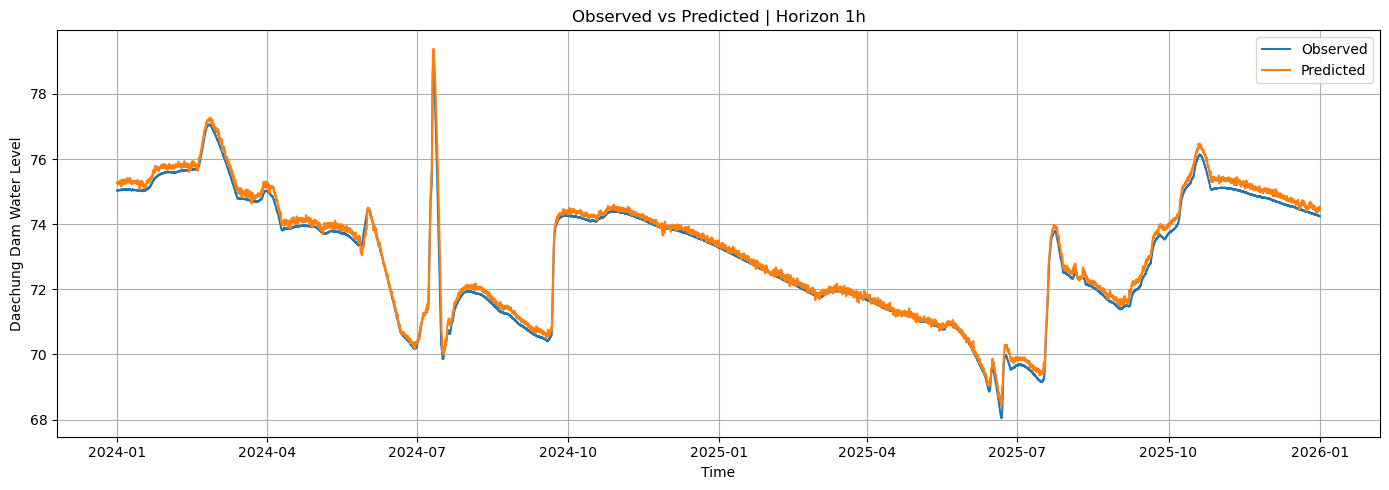


####################################################################################################
Best model evaluation | Horizon 3h
####################################################################################################

Horizon 3h
Calibration NSE: 0.9960
Test NSE       : 0.9874
Calibration prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_3/horizon_3_cal_predictions.csv
Test prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_3/horizon_3_test_predictions.csv


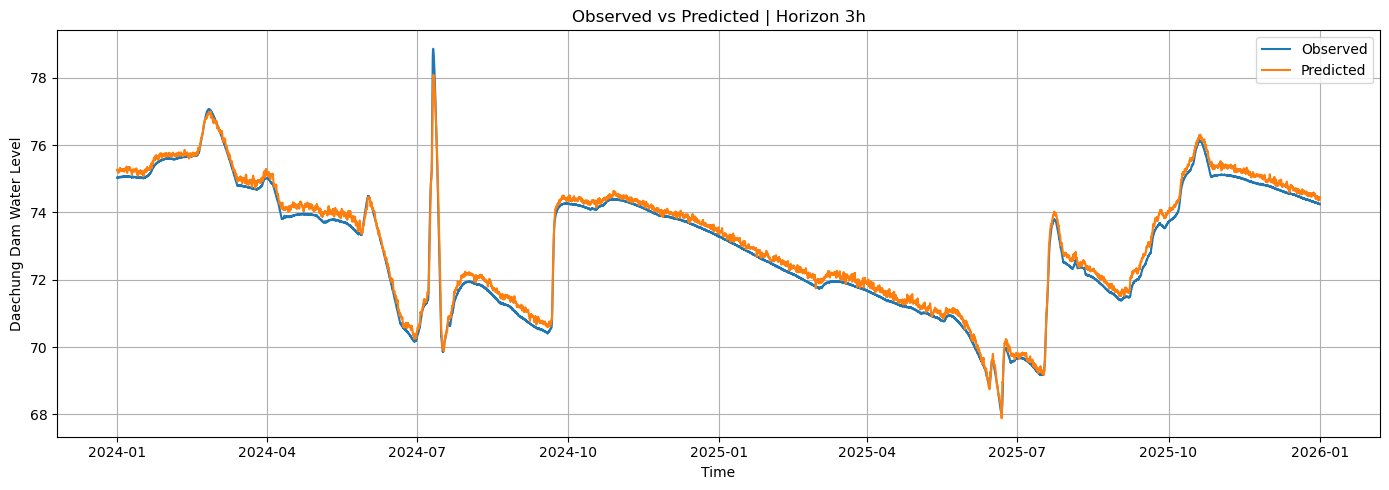


####################################################################################################
Best model evaluation | Horizon 6h
####################################################################################################

Horizon 6h
Calibration NSE: 0.9972
Test NSE       : 0.9925
Calibration prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_6/horizon_6_cal_predictions.csv
Test prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_6/horizon_6_test_predictions.csv


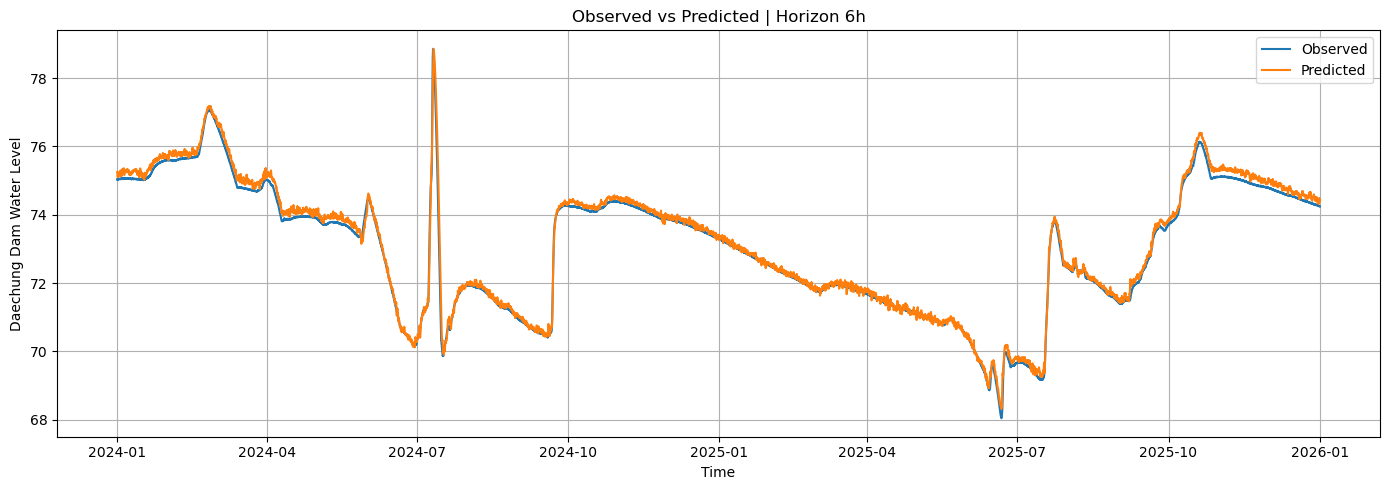


####################################################################################################
Best model evaluation | Horizon 9h
####################################################################################################

Horizon 9h
Calibration NSE: 0.9952
Test NSE       : 0.9866
Calibration prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_9/horizon_9_cal_predictions.csv
Test prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_9/horizon_9_test_predictions.csv


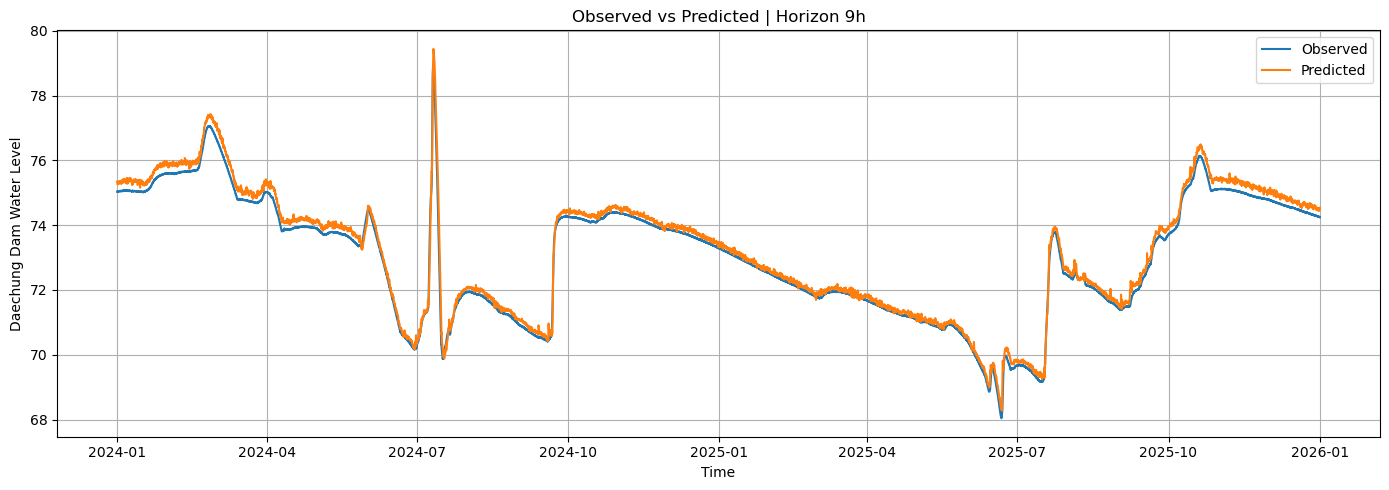


####################################################################################################
Best model evaluation | Horizon 12h
####################################################################################################

Horizon 12h
Calibration NSE: 0.9962
Test NSE       : 0.9890
Calibration prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_12/horizon_12_cal_predictions.csv
Test prediction saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/horizon_12/horizon_12_test_predictions.csv


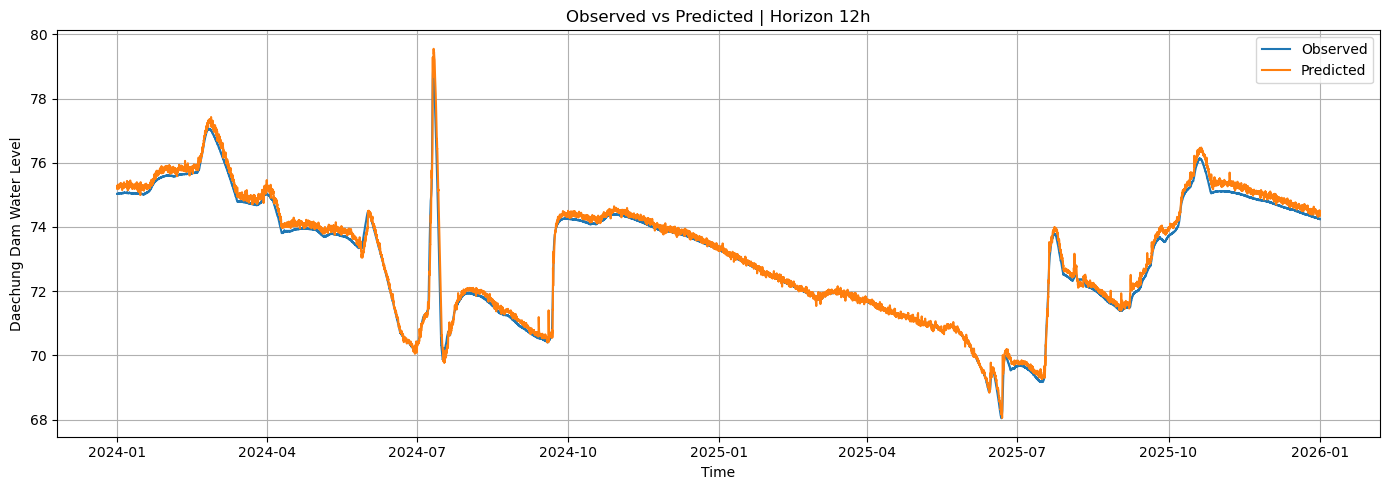


All horizon calibration metrics saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/all_horizon_cal_metrics.csv
All horizon test metrics saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/all_horizon_test_metrics.csv
   forecast_horizon  best_trial_number  window_size   cal_NSE   cal_KGE  \
0                 1                 19            8  0.996087  0.992447   
1                 3                 16           48  0.996015  0.984697   
2                 6                  1           48  0.997243  0.983569   
3                 9                  8           72  0.995188  0.984774   
4                12                  4           24  0.996159  0.965004   

   cal_RMSE   cal_MAE  
0  0.149635  0.103788  
1  0.151007  0.125944  
2  0.125596  0.086775  
3  0.165946  0.129630  
4  0.148261  0.100356  
   forecast_

In [28]:
# ============================================================
# 15. Best Model Calibration & Test Evaluation
# ============================================================

all_cal_metrics = []
all_test_metrics = []

for forecast_horizon in FORECAST_HORIZON_LIST:
    print("\n" + "#" * 100)
    print(f"Best model evaluation | Horizon {forecast_horizon}h")
    print("#" * 100)

    MODEL_DIR_H = EXP_MODEL_DIR / f"horizon_{forecast_horizon}"
    RESULT_DIR_H = EXP_RESULT_DIR / f"horizon_{forecast_horizon}"
    FIGURE_DIR_H = EXP_FIGURE_DIR / f"horizon_{forecast_horizon}"

    best_model_path = MODEL_DIR_H / "best_overall_model.pt"
    best_scaler_x_path = MODEL_DIR_H / "best_overall_scaler_X.pkl"
    best_scaler_y_path = MODEL_DIR_H / "best_overall_scaler_y.pkl"

    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
    scaler_X = joblib.load(best_scaler_x_path)
    scaler_y = joblib.load(best_scaler_y_path)

    best_params = checkpoint["params"]
    window_size = checkpoint["window_size"]

    X_all_scaled = scaler_X.transform(df[feature_cols].values)
    y_all_scaled = scaler_y.transform(df[[TARGET_COL]].values)

    X, y, target_times = make_window_dataset(
        X_values=X_all_scaled,
        y_values=y_all_scaled,
        time_values=df[TIME_COL].values,
        window_size=window_size,
        forecast_horizon=forecast_horizon
    )

    target_times = pd.to_datetime(target_times)

    cal_mask = (target_times >= VAL_END) & (target_times < CAL_END)
    test_mask = target_times >= CAL_END

    X_cal, y_cal = X[cal_mask], y[cal_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    time_cal = target_times[cal_mask]
    time_test = target_times[test_mask]

    cal_dataset = TimeSeriesDataset(X_cal, y_cal)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    cal_loader = DataLoader(
        cal_dataset,
        batch_size=best_params["batch_size"],
        shuffle=False,
        num_workers=0
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=best_params["batch_size"],
        shuffle=False,
        num_workers=0
    )

    model = LSTMRegressor(
        input_size=X_test.shape[2],
        hidden_size=best_params["hidden_size"],
        num_layers=best_params["num_layers"],
        dropout=best_params["dropout"],
        dense_size=best_params["dense_size"]
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    # Calibration prediction
    y_cal_scaled_true, y_cal_scaled_pred = predict_model(model, cal_loader, device)

    y_cal_true = scaler_y.inverse_transform(y_cal_scaled_true)
    y_cal_pred = scaler_y.inverse_transform(y_cal_scaled_pred)

    cal_metrics = evaluate_predictions(y_cal_true, y_cal_pred)

    cal_pred_df = pd.DataFrame({
        "datetime": time_cal,
        "observed": y_cal_true.reshape(-1),
        "predicted": y_cal_pred.reshape(-1),
        "absolute_error": np.abs(y_cal_true.reshape(-1) - y_cal_pred.reshape(-1)),
        "forecast_horizon": forecast_horizon,
        "window_size": window_size,
        "best_trial_number": checkpoint["trial_number"]
    })

    cal_pred_path = RESULT_DIR_H / f"horizon_{forecast_horizon}_cal_predictions.csv"
    cal_pred_df.to_csv(cal_pred_path, index=False, encoding="utf-8-sig")

    all_cal_metrics.append({
        "forecast_horizon": forecast_horizon,
        "best_trial_number": checkpoint["trial_number"],
        "window_size": window_size,
        "cal_NSE": cal_metrics["NSE"],
        "cal_KGE": cal_metrics["KGE"],
        "cal_RMSE": cal_metrics["RMSE"],
        "cal_MAE": cal_metrics["MAE"],
    })

    # Test prediction
    y_test_scaled_true, y_test_scaled_pred = predict_model(model, test_loader, device)

    y_test_true = scaler_y.inverse_transform(y_test_scaled_true)
    y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)

    test_metrics = evaluate_predictions(y_test_true, y_test_pred)

    pred_df = pd.DataFrame({
        "datetime": time_test,
        "observed": y_test_true.reshape(-1),
        "predicted": y_test_pred.reshape(-1),
        "absolute_error": np.abs(y_test_true.reshape(-1) - y_test_pred.reshape(-1)),
        "forecast_horizon": forecast_horizon,
        "window_size": window_size,
        "best_trial_number": checkpoint["trial_number"]
    })

    pred_path = RESULT_DIR_H / f"horizon_{forecast_horizon}_test_predictions.csv"
    pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

    all_test_metrics.append({
        "forecast_horizon": forecast_horizon,
        "best_trial_number": checkpoint["trial_number"],
        "window_size": window_size,
        "hidden_size": best_params["hidden_size"],
        "num_layers": best_params["num_layers"],
        "dropout": best_params["dropout"],
        "dense_size": best_params["dense_size"],
        "learning_rate": best_params["learning_rate"],
        "weight_decay": best_params["weight_decay"],
        "batch_size": best_params["batch_size"],
        "patience": best_params["patience"],
        "test_NSE": test_metrics["NSE"],
        "test_KGE": test_metrics["KGE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_MAE": test_metrics["MAE"],
    })

    print(f"\nHorizon {forecast_horizon}h")
    print(f"Calibration NSE: {cal_metrics['NSE']:.4f}")
    print(f"Test NSE       : {test_metrics['NSE']:.4f}")
    print("Calibration prediction saved:", cal_pred_path)
    print("Test prediction saved:", pred_path)

    plt.figure(figsize=(14, 5))
    plt.plot(pred_df["datetime"], pred_df["observed"], label="Observed")
    plt.plot(pred_df["datetime"], pred_df["predicted"], label="Predicted")
    plt.xlabel("Time")
    plt.ylabel("Daechung Dam Water Level")
    plt.title(f"Observed vs Predicted | Horizon {forecast_horizon}h")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    fig_path = FIGURE_DIR_H / f"horizon_{forecast_horizon}_test_prediction.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

cal_metrics_df = pd.DataFrame(all_cal_metrics)
test_metrics_df = pd.DataFrame(all_test_metrics)

cal_metrics_path = EXP_RESULT_DIR / "all_horizon_cal_metrics.csv"
test_metrics_path = EXP_RESULT_DIR / "all_horizon_test_metrics.csv"

cal_metrics_df.to_csv(cal_metrics_path, index=False, encoding="utf-8-sig")
test_metrics_df.to_csv(test_metrics_path, index=False, encoding="utf-8-sig")

print("\nAll horizon calibration metrics saved:", cal_metrics_path)
print("All horizon test metrics saved:", test_metrics_path)

print(cal_metrics_df)
print(test_metrics_df)


In [29]:
baseline_path = EXP_RESULT_DIR / "persistence_baseline_metrics.csv"
baseline_df = pd.read_csv(baseline_path)

display(baseline_df)

,forecast_horizon,val_NSE_persistence,val_KGE_persistence,val_RMSE_persistence,val_MAE_persistence,cal_NSE_persistence,cal_KGE_persistence,cal_RMSE_persistence,cal_MAE_persistence,test_NSE_persistence,test_KGE_persistence,test_RMSE_persistence,test_MAE_persistence
0,1,0.999946,0.999973,0.013513,0.005840,0.999966,0.999960,0.013984,0.005593,0.999944,0.999965,0.013888,0.005766
1,3,0.999606,0.999803,0.036438,0.013313,0.999734,0.999829,0.038985,0.013909,0.999576,0.999778,0.038097,0.013341
2,6,0.998515,0.999257,0.070745,0.024148,0.998992,0.999452,0.075938,0.025499,0.998384,0.999182,0.074328,0.024329
3,9,0.996815,0.998407,0.103607,0.033965,0.997833,0.998869,0.111350,0.036389,0.996500,0.998240,0.109399,0.034424
4,12,0.994594,0.997297,0.134975,0.043666,0.996320,0.998110,0.145108,0.047257,0.993998,0.996989,0.143266,0.044787


In [32]:
# ============================================================
# Additional metrics: NRMSE, PBIAS
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def nse_score(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    return 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

def kge_score(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)

    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae_score(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def nrmse_range_score(y_true, y_pred):
    rmse = rmse_score(y_true, y_pred)
    data_range = np.max(y_true) - np.min(y_true)
    return rmse / data_range * 100

def nrmse_mean_score(y_true, y_pred):
    rmse = rmse_score(y_true, y_pred)
    return rmse / np.mean(y_true) * 100

def pbias_score(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    return 100 * np.sum(y_pred - y_true) / np.sum(y_true)


metric_rows = []

for h in FORECAST_HORIZON_LIST:
    pred_path = EXP_RESULT_DIR / f"horizon_{h}" / f"horizon_{h}_test_predictions.csv"
    pred_df = pd.read_csv(pred_path)

    y_true = pred_df["observed"].values
    y_pred = pred_df["predicted"].values

    metric_rows.append({
        "forecast_horizon": h,
        "NSE": nse_score(y_true, y_pred),
        "KGE": kge_score(y_true, y_pred),
        "RMSE_m": rmse_score(y_true, y_pred),
        "MAE_m": mae_score(y_true, y_pred),
        "NRMSE_range_percent": nrmse_range_score(y_true, y_pred),
        "NRMSE_mean_percent": nrmse_mean_score(y_true, y_pred),
        "PBIAS_percent": pbias_score(y_true, y_pred),
    })

final_metric_df = pd.DataFrame(metric_rows)

display(final_metric_df)

metric_path = EXP_RESULT_DIR / "final_test_metrics_with_nrmse_pbias.csv"
final_metric_df.to_csv(metric_path, index=False, encoding="utf-8-sig")

print("Saved:", metric_path)

,forecast_horizon,NSE,KGE,RMSE_m,MAE_m,NRMSE_range_percent,NRMSE_mean_percent,PBIAS_percent
0,1,0.988883,0.983869,0.194978,0.160486,1.802014,0.267078,0.209360
1,3,0.987409,0.991985,0.207500,0.188624,1.917742,0.284231,0.245572
2,6,0.992470,0.976564,0.160461,0.123505,1.483004,0.219798,0.147957
3,9,0.986552,0.968079,0.214440,0.183513,1.981883,0.293737,0.240828
4,12,0.989039,0.968649,0.193597,0.147106,1.789255,0.265187,0.169413


Saved: /home/u2022144048/grad_project/daechung_waterlevel_lstm/outputs/lstm_dam_weather_horizon_1_3_6_9_12_window_optuna_stable_es/results/final_test_metrics_with_nrmse_pbias.csv


In [33]:
h = 12
w = 24
idx = 1000

raw_X = df[feature_cols].values
raw_y = df[[TARGET_COL]].values
raw_time = df[TIME_COL].values

X_tmp, y_tmp, time_tmp = make_window_dataset(
    X_values=raw_X,
    y_values=raw_y,
    time_values=raw_time,
    window_size=w,
    forecast_horizon=h
)

print("Last input time:", df[TIME_COL].iloc[idx + w - 1])
print("Target time:", time_tmp[idx])
print("Expected target time:", df[TIME_COL].iloc[idx + w + h - 1])
print("Time difference:", pd.Timestamp(time_tmp[idx]) - df[TIME_COL].iloc[idx + w - 1])

print("Last input target:", df[TARGET_COL].iloc[idx + w - 1])
print("Target value:", y_tmp[idx, 0])
print("Expected target value:", df[TARGET_COL].iloc[idx + w + h - 1])

Last input time: 2006-02-12 15:00:00
Target time: 2006-02-13T03:00:00.000000000
Expected target time: 2006-02-13 03:00:00
Time difference: 0 days 12:00:00
Last input target: 68.41
Target value: 68.37
Expected target value: 68.37
